In [47]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import re
import pandas as pd
import torch

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

from utils import (
    load_graph_from_txt, 
    dirichlet_energy_laplacian, 
    compute_rule_following_accuracy_over_records, 
    parse_tree_text,
    tree_to_graph,
    build_word_centroid_map,
    aggregate_cluster_centroids,
    )

# Paper Grid

In [ ]:
VOCAB_PATH = Path("../data/paper-tkid-map.txt")
grid_folder = "paper_grid"
structure_name = "paper_grid"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [32]:
ctx = 3000
WIN = 200          # ampiezza finestra interna

all_results = []   # lista di dict: uno per finestra

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)  # numero token effettivamente presenti nel file (<= 500, spesso 500)
file_global_start = max(0, ctx - T_file)   # inizio globale coperto dal file
file_global_end = ctx                       # fine globale esclusiva

# finestre locali nel file: [0:100), [100:200), ...
for t0 in range(0, T_file, WIN):
    t1 = min(t0 + WIN, T_file)

    # range globale corrispondente (solo per logging/debug)
    g0 = file_global_start + t0
    g1 = file_global_start + t1

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, local=[{t0}:{t1}), global=[{g0}:{g1})"
    )

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    X = centroids.astype(np.float64).copy()
    X = X - X.mean(axis=0, keepdims=True)  # center per feature
    X = X / np.clip(X.std(axis=0, keepdims=True), 1e-8, None)  # std per feature

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

    # opzionale ma molto utile: allinea al grafo (se nella finestra mancano nodi)
    common = [lab for lab in labels if lab in G.nodes()]
    if len(common) < 2:
        print(f"  [ctx={ctx}] window [{g0}:{g1}) -> troppo pochi nodi comuni al grafo ({len(common)})")
        E = np.nan
    else:
        idx = {lab: i for i, lab in enumerate(labels)}
        X_common = np.stack([X[idx[lab]] for lab in common], axis=0)

        # subgrafo indotto sui nodi presenti nella finestra
        G_sub = G.subgraph(common).copy()

        # se non ci sono archi nel subgrafo, energia non informativa
        if G_sub.number_of_edges() == 0:
            E = np.nan
            print(f"  [ctx={ctx}] window [{g0}:{g1}) -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_common)

    # print(f"  CTX={ctx} | local=[{t0}:{t1}) | global=[{g0}:{g1}) | E={E}")

    all_results.append({
        "ctx": ctx,
        "t_start_local": t0, "t_end_local": t1,
        "t_start_global": g0, "t_end_global": g1,
        "energy": E,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
    })

  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'bird' has only 19 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'mango' has only 10 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'code' has only 8 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'milk' has only 22 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'phone' has only 6 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'plane' has only 13 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'egg' has only 10 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'car' has only 21 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'rock' has onl

In [23]:

# # === Carica file ===
# logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# # Carica
# data = torch.load(logit_file, map_location="cpu")

# records = data.get("records", [])

# for rec in records:
#     pos1 = rec.get("token_position_1based")
#     observed = rec.get("input_token_str", rec.get("last_input_token_str", ""))

#     print(f"\nToken #{pos1} | osservato: {repr(observed)}")
#     print("-" * 60)

#     # Se hai top_decoded usa quello (più leggibile), altrimenti fallback su top_tokens
#     pred_strings = rec.get("top_decoded") or rec.get("top_tokens", [])
#     pred_probs = rec.get("top_probs", [])

#     for s, p in zip(pred_strings, pred_probs):
#         print(f"{repr(s):<20}  {p:.6f}")

In [29]:
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)

# df_rule[[
#     "token_position_1based",
#     "observed_raw",
#     "rule_following_mass_topk",
#     "num_matched_preds",
#     "matched_preds"
# ]]

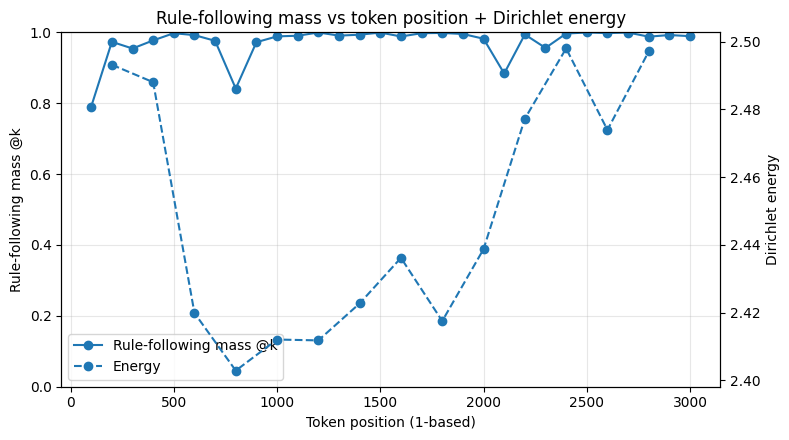

In [33]:
df = pd.DataFrame(all_results)

# 2) Togli finestre senza energia
df_plot = df.dropna(subset=["energy"]).copy()

# 3) Ordina (sempre meglio)
df_plot = df_plot.sort_values(["ctx", "t_end_global"])

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# Asse Y sinistro: rule-following mass
ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o",
    label="Rule-following mass @k"
)
ax1.set_xlabel("Token position (1-based)")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0,1)

# Asse Y destro: energy
ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_end_global"][:-1],
    df_plot["energy"][:-1],
    marker="o",
    linestyle="--",
    label="Energy"
)
ax2.set_ylabel("Dirichlet energy")

# Titolo
plt.title("Rule-following mass vs token position + Dirichlet energy")

# Legenda combinata (linee da entrambi gli assi)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

# OUR Grid

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "grid_16"
structure_name = "grid_dataset"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)


In [ ]:

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'blackout' has only 11 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'peanuts' has only 6 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'potassium' has only 11 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'vitae' has only 6 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'nonatomic' has only 21 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'standby' has only 10 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'mafia' has only 19 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'flu' has only 20 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: 

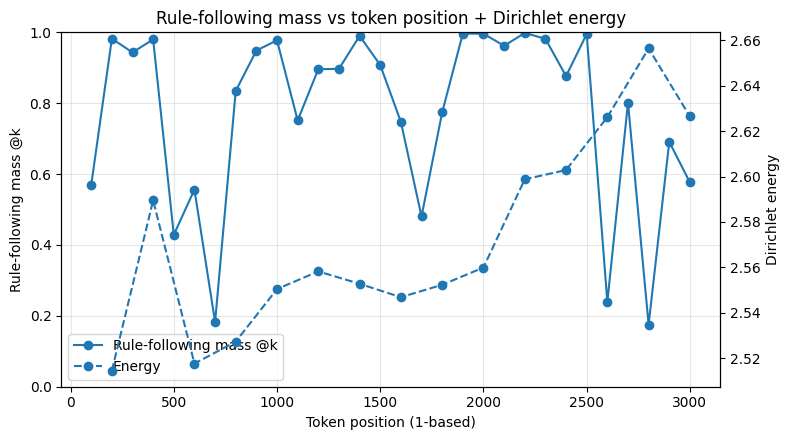

In [39]:
ctx = 3000
WIN = 200          # ampiezza finestra interna

all_results = []   # lista di dict: uno per finestra

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)  # numero token effettivamente presenti nel file (<= 500, spesso 500)
file_global_start = max(0, ctx - T_file)   # inizio globale coperto dal file
file_global_end = ctx                       # fine globale esclusiva

# finestre locali nel file: [0:100), [100:200), ...
for t0 in range(0, T_file, WIN):
    t1 = min(t0 + WIN, T_file)

    # range globale corrispondente (solo per logging/debug)
    g0 = file_global_start + t0
    g1 = file_global_start + t1

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, local=[{t0}:{t1}), global=[{g0}:{g1})"
    )

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    X = centroids.astype(np.float64).copy()
    X = X - X.mean(axis=0, keepdims=True)  # center per feature
    X = X / np.clip(X.std(axis=0, keepdims=True), 1e-8, None)  # std per feature

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

    # opzionale ma molto utile: allinea al grafo (se nella finestra mancano nodi)
    common = [lab for lab in labels if lab in G.nodes()]
    if len(common) < 2:
        print(f"  [ctx={ctx}] window [{g0}:{g1}) -> troppo pochi nodi comuni al grafo ({len(common)})")
        E = np.nan
    else:
        idx = {lab: i for i, lab in enumerate(labels)}
        X_common = np.stack([X[idx[lab]] for lab in common], axis=0)

        # subgrafo indotto sui nodi presenti nella finestra
        G_sub = G.subgraph(common).copy()

        # se non ci sono archi nel subgrafo, energia non informativa
        if G_sub.number_of_edges() == 0:
            E = np.nan
            print(f"  [ctx={ctx}] window [{g0}:{g1}) -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_common)

    # print(f"  CTX={ctx} | local=[{t0}:{t1}) | global=[{g0}:{g1}) | E={E}")

    all_results.append({
        "ctx": ctx,
        "t_start_local": t0, "t_end_local": t1,
        "t_start_global": g0, "t_end_global": g1,
        "energy": E,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
    })
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)

# 2) Togli finestre senza energia
df_plot = df.dropna(subset=["energy"]).copy()

# 3) Ordina (sempre meglio)
df_plot = df_plot.sort_values(["ctx", "t_end_global"])

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# Asse Y sinistro: rule-following mass
ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o",
    label="Rule-following mass @k"
)
ax1.set_xlabel("Token position (1-based)")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0,1)

# Asse Y destro: energy
ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_end_global"][:-1],
    df_plot["energy"][:-1],
    marker="o",
    linestyle="--",
    label="Energy"
)
ax2.set_ylabel("Dirichlet energy")

# Titolo
plt.title("Rule-following mass vs token position + Dirichlet energy")

# Legenda combinata (linee da entrambi gli assi)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

# 4 levels tree

Grid - #nodi: 31 #archi: 30


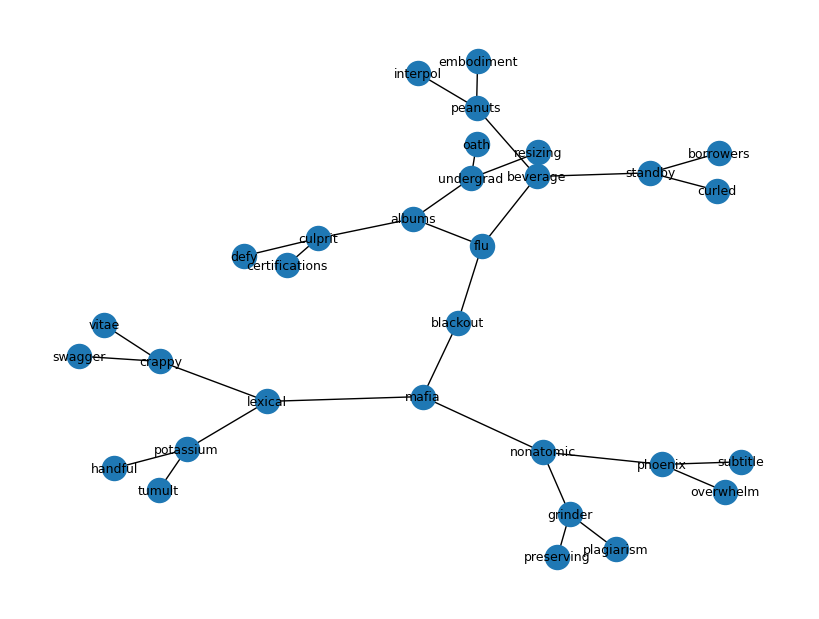

In [42]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "tree_4_levels"
structure_name = "bin_tree"

STRUCT_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")

hp_tree4 = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(STRUCT_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=9
)
plt.show()

  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'blackout' has only 12 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'potassium' has only 15 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'nonatomic' has only 18 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'mafia' has only 21 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'flu' has only 8 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'albums' has only 10 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'grinder' has only 9 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning: token 'culprit' has only 19 occurrences in [0:200] (requested 50)
  [ctx=3000, local=[0:200), global=[0:200)] Warning:

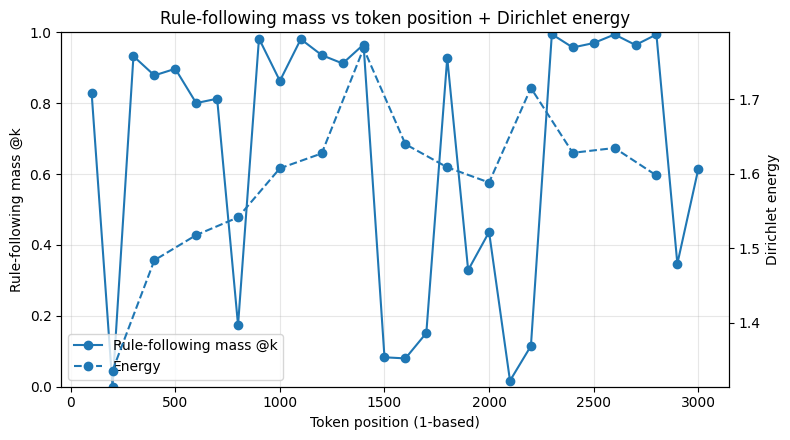

In [45]:
ctx = 3000
WIN = 200          # ampiezza finestra interna

all_results = []   # lista di dict: uno per finestra

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)  # numero token effettivamente presenti nel file (<= 500, spesso 500)
file_global_start = max(0, ctx - T_file)   # inizio globale coperto dal file
file_global_end = ctx                       # fine globale esclusiva

# finestre locali nel file: [0:100), [100:200), ...
for t0 in range(0, T_file, WIN):
    t1 = min(t0 + WIN, T_file)

    # range globale corrispondente (solo per logging/debug)
    g0 = file_global_start + t0
    g1 = file_global_start + t1

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_tree4.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, local=[{t0}:{t1}), global=[{g0}:{g1})"
    )

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    X = centroids.astype(np.float64).copy()
    X = X - X.mean(axis=0, keepdims=True)  # center per feature
    X = X / np.clip(X.std(axis=0, keepdims=True), 1e-8, None)  # std per feature

    labels = [hp_tree4.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

    # opzionale ma molto utile: allinea al grafo (se nella finestra mancano nodi)
    common = [lab for lab in labels if lab in G.nodes()]
    if len(common) < 2:
        print(f"  [ctx={ctx}] window [{g0}:{g1}) -> troppo pochi nodi comuni al grafo ({len(common)})")
        E = np.nan
    else:
        idx = {lab: i for i, lab in enumerate(labels)}
        X_common = np.stack([X[idx[lab]] for lab in common], axis=0)

        # subgrafo indotto sui nodi presenti nella finestra
        G_sub = G.subgraph(common).copy()

        # se non ci sono archi nel subgrafo, energia non informativa
        if G_sub.number_of_edges() == 0:
            E = np.nan
            print(f"  [ctx={ctx}] window [{g0}:{g1}) -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_common)

    # print(f"  CTX={ctx} | local=[{t0}:{t1}) | global=[{g0}:{g1}) | E={E}")

    all_results.append({
        "ctx": ctx,
        "t_start_local": t0, "t_end_local": t1,
        "t_start_global": g0, "t_end_global": g1,
        "energy": E,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
    })
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)

# 2) Togli finestre senza energia
df_plot = df.dropna(subset=["energy"]).copy()

# 3) Ordina (sempre meglio)
df_plot = df_plot.sort_values(["ctx", "t_end_global"])

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# Asse Y sinistro: rule-following mass
ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o",
    label="Rule-following mass @k"
)
ax1.set_xlabel("Token position (1-based)")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0,1)

# Asse Y destro: energy
ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_end_global"][:-1],
    df_plot["energy"][:-1],
    marker="o",
    linestyle="--",
    label="Energy"
)
ax2.set_ylabel("Dirichlet energy")

# Titolo
plt.title("Rule-following mass vs token position + Dirichlet energy")

# Legenda combinata (linee da entrambi gli assi)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

# clustered tree

In [48]:
clustered_tree = """
root
├── c1.1
│   ├── c2.1
│   │   ├── c3.1
│   │   └── c3.2
│   └── c2.2
│       ├── c3.3
│       └── c3.4
└── c1.2
    ├── c2.3
    │   ├── c3.5
    │   └── c3.6
    └── c2.4
        ├── c3.7
        └── c3.8
"""

cluster_to_words = {
    "root": ("blackout", "vitae", "swagger"),

    "c1.1": ("mafia", "tumult", "handful"),
    "c1.2": ("flu", "overwhelm", "subtitle"),

    "c2.1": ("lexical", "preserving", "plagiarism"),
    "c2.2": ("nonatomic", "borrowers", "curled"),
    "c2.3": ("beverage", "embodiment", "interpol"),
    "c2.4": ("albums", "resizing", "oath"),

    "c3.1": ("crappy", "defy", "certifications"),
    "c3.2": ("potassium", "albeit", "mote"),
    "c3.3": ("phoenix", "tasty", "wealthiest"),
    "c3.4": ("grinder", "unconditional", "intends"),
    "c3.5": ("standby", "flaming", "fabs"),
    "c3.6": ("peanuts", "stricter", "improvised"),
    "c3.7": ("undergrad", "soar", "finns"),
    "c3.8": ("culprit", "righteous", "intimately"),
}

In [49]:
CTX_LENS = [300, 600, 1200, 1800]
EMB_DIR     = Path("../embeddings/one_random_walk/tree_clusters_3_levels/")

# 1) costruisci una volta il grafo clustered
root_c, edges_c = parse_tree_text(clustered_tree)
G_cluster = tree_to_graph(root_c, edges_c, directed=False)

# check coerenza mappa cluster -> parole
assert set(cluster_to_words.keys()) == set(G_cluster.nodes()), (
    f"Mismatch cluster labels.\n"
    f"Solo in mappa: {set(cluster_to_words.keys()) - set(G_cluster.nodes())}\n"
    f"Solo nel grafo: {set(G_cluster.nodes()) - set(cluster_to_words.keys())}"
)

energies = []

for ctx in CTX_LENS:
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, k=10)
    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    # 2) dizionario parola -> centroide parola
    word_to_centroid = build_word_centroid_map(centroid_ids, centroids, hp_grid.id_to_word)

    # 3) aggrega ai cluster (un vettore per nodo del grafo clustered)
    cluster_labels, X_cluster = aggregate_cluster_centroids(
        G_cluster=G_cluster,
        cluster_to_words=cluster_to_words,
        word_to_centroid=word_to_centroid,
        agg="mean",   # root = media dei vettori delle parole nel tuple
    )

    # # 4) standardizzazione (come nel paper, per-feature)
    # X_cluster = X_cluster.astype(np.float64).copy()
    # X_cluster = X_cluster - X_cluster.mean(axis=0, keepdims=True)                 # center per feature
    # X_cluster = X_cluster / np.clip(X_cluster.std(axis=0, keepdims=True), 1e-8, None)   

    # 5) energia sul grafo clustered
    E = dirichlet_energy_laplacian(G_cluster, cluster_labels, X_cluster)

    # (opzionale) metriche normalizzate per confronti
    m = G_cluster.number_of_edges()
    d = X_cluster.shape[1]
    E_per_edge = E / m
    E_per_edge_dim = E / (m * d)

    print(f"[ctx={ctx}] E={E:.6f}  E/|E|={E_per_edge:.6f}  E/(|E|d)={E_per_edge_dim:.8f}")
    energies.append(E)

  [] Warning: token 'blackout' has only 6 occurrences in [0:302] (requested 10)
  [] Warning: token 'peanuts' has only 1 occurrences in [0:302] (requested 10)
  [] Warning: token 'potassium' has only 5 occurrences in [0:302] (requested 10)
  [] Warning: token 'nonatomic' has only 9 occurrences in [0:302] (requested 10)
  [] Warning: token 'standby' has only 4 occurrences in [0:302] (requested 10)
  [] Warning: token 'mafia' has only 9 occurrences in [0:302] (requested 10)
  [] Warning: token 'grinder' has only 2 occurrences in [0:302] (requested 10)
  [] Warning: token 'culprit' has only 5 occurrences in [0:302] (requested 10)
  [] Warning: token 'undergrad' has only 6 occurrences in [0:302] (requested 10)
  [] Warning: token 'crappy' has only 2 occurrences in [0:302] (requested 10)
  [] Warning: token 'phoenix' has only 1 occurrences in [0:302] (requested 10)
Attenzione: parole mancanti in alcuni cluster:
  root: ['swagger']
  c1.1: ['tumult', 'handful']
  c2.1: ['preserving', 'plagia

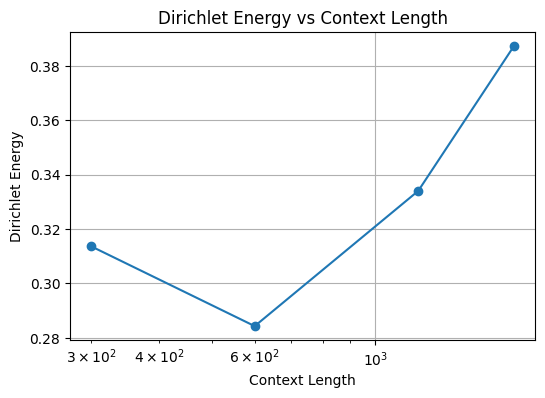

In [50]:
plt.figure(figsize=(6, 4))
plt.plot(CTX_LENS, energies, marker="o")
plt.title("Dirichlet Energy vs Context Length")
plt.xlabel("Context Length")
plt.xscale("log")
plt.ylabel("Dirichlet Energy")
plt.grid(True)
plt.show()